In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords 
from wordcloud import WordCloud
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/Atharva/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
data = pd.read_csv('spam_ham_dataset.csv')
data

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [37]:
data.shape

(5171, 4)

Balancing

<Axes: xlabel='label', ylabel='count'>

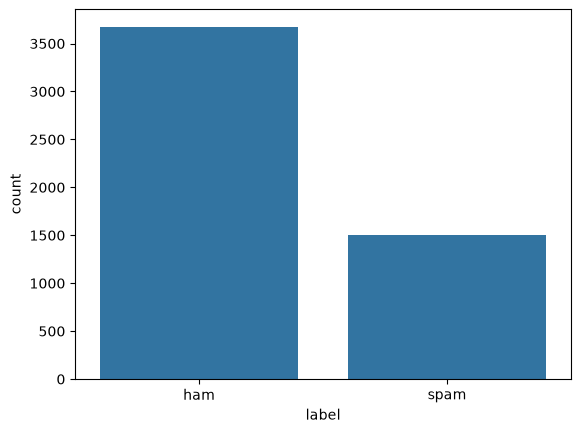

In [38]:
sns.countplot(x='label', data=data) 

In [39]:
# As the count of ham(not spam) emails is much larger training a model directly on this data will create bias so downsize ham emails
ham_mail = data[data['label'] == 'ham']
spam_mail = data[data['label'] == 'spam']

ham_mail = ham_mail.sample(n=len(spam_mail), random_state=42)
balanced_data = pd.concat([ham_mail, spam_mail]).reset_index(drop=True)

balanced_data

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject: conoco - big cowboy\r\ndarren :\r\ni ...,0
1,2982,ham,Subject: feb 01 prod : sale to teco gas proces...,0
2,2711,ham,Subject: california energy crisis\r\ncaliforni...,0
3,3116,ham,Subject: re : nom / actual volume for april 23...,0
4,1314,ham,Subject: eastrans nomination changes effective...,0
...,...,...,...,...
2993,4381,spam,Subject: pictures\r\nstreamlined denizen ajar ...,1
2994,4979,spam,Subject: penny stocks are about timing\r\nnoma...,1
2995,4162,spam,Subject: anomaly boys from 3881\r\nuosda apapr...,1
2996,4365,spam,Subject: slutty milf wants to meet you\r\ntake...,1


<Axes: xlabel='label', ylabel='count'>

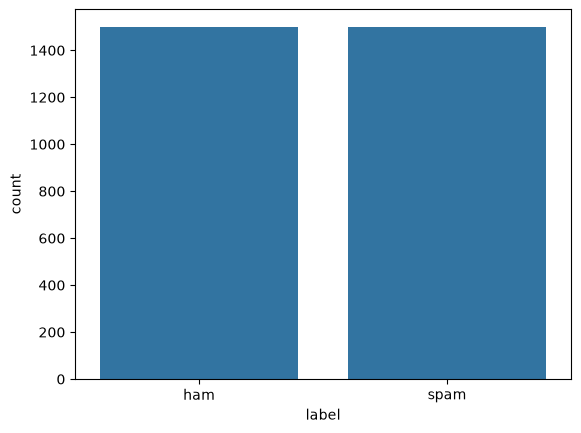

In [40]:
sns.countplot(x=balanced_data['label'])

Cleaning

In [41]:
# Removing the subject word 
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0
...,...,...,...,...
2993,4381,spam,: pictures\r\nstreamlined denizen ajar chased\...,1
2994,4979,spam,: penny stocks are about timing\r\nnomad inter...,1
2995,4162,spam,: anomaly boys from 3881\r\nuosda apaproved ml...,1
2996,4365,spam,: slutty milf wants to meet you\r\ntake that !...,1


In [42]:
# Removing the punctuation
punct_list = string.punctuation
def remove_punct(text):
    temp = str.maketrans('','',punct_list) # take 3 parameters 1st - what to change, 2nd - change to what, 3rd - what to delete
    return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punct(x)) # using lambda single data value is used to process
balanced_data

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0
...,...,...,...,...
2993,4381,spam,pictures\r\nstreamlined denizen ajar chased\r...,1
2994,4979,spam,penny stocks are about timing\r\nnomad intern...,1
2995,4162,spam,anomaly boys from 3881\r\nuosda apaproved mle...,1
2996,4365,spam,slutty milf wants to meet you\r\ntake that \r...,1


In [43]:
# remove the stopwords (is, the, at)
def remove_stop_words(text):
    stop_words = stopwords.words('english')
    imp_words = []

    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)
    
    output = ' '.join(imp_words)
    return output

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_stop_words(x))
balanced_data

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0
...,...,...,...,...
2993,4381,spam,pictures streamlined denizen ajar chased heave...,1
2994,4979,spam,penny stocks timing nomad international inc nd...,1
2995,4162,spam,anomaly boys 3881 uosda apaproved mledms heure...,1
2996,4365,spam,slutty milf wants meet take ilaa liqaa,1


Visualisation Word Cloud (to present the words according to size (big = more importance in spam/ham))

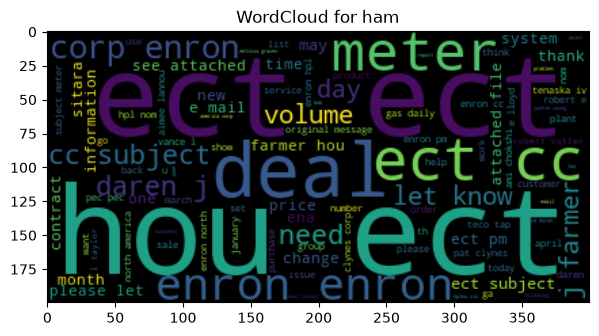

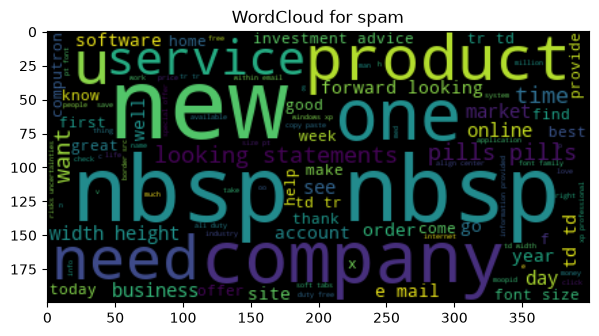

In [44]:
def plot_word_cloud(data,typ):
    email_corpus = ' '.join(data['text']) # corpus means large structutered data of text useful for analysis, modeling, etc
    wc = WordCloud(background_color='black', max_words=100).generate(email_corpus)
    plt.figure(figsize=(7,7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ}')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ = 'ham')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ = 'spam')

In [45]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [46]:
xtrain, xtest, ytrain, ytest = train_test_split(balanced_data['text'], balanced_data['label'], random_state=42)

In [47]:
tokenizer = Tokenizer() # convert words to a unique integer id
tokenizer.fit_on_texts(xtrain)

train_sequence = tokenizer.texts_to_sequences(xtrain)
test_sequence = tokenizer.texts_to_sequences(xtest)

mxlen = 100 # padding is used to make sure the data is of mxlen dimension for neural networks to work 
train_sequence = pad_sequences(train_sequence, maxlen=mxlen, padding='post', truncating='post')
test_sequence = pad_sequences(test_sequence, maxlen=mxlen, padding='post', truncating='post')

ytrain = (ytrain == 'spam').astype(int)
ytest = (ytest == 'spam').astype(int)

In [48]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=mxlen), # learns vector representation 
    tf.keras.layers.LSTM(16), # capture pattern in data
    tf.keras.layers.Dense(32, activation='relu'), # extract relevant features 
    tf.keras.layers.Dense(1, activation='sigmoid') # predict spam or ham
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

/Users/Atharva/Documents/Machine Learning/tf_env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True) # if accuracy drops consecutively 3 times stop fitting best weights make sure the best weights on any epochs is used
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0) # if loss drops consecutively 2 times drop learning rate by 0.5

history = model.fit(
    train_sequence, ytrain,
    validation_data=(test_sequence, ytest),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20


/Users/Atharva/Documents/Machine Learning/tf_env/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:1288: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5520 - loss: 0.6909 - val_accuracy: 0.5707 - val_loss: 0.6831 - learning_rate: 0.0010
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8372 - loss: 0.3954 - val_accuracy: 0.9507 - val_loss: 0.1883 - learning_rate: 0.0010
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9551 - loss: 0.1714 - val_accuracy: 0.9600 - val_loss: 0.1682 - learning_rate: 0.0010
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9635 - loss: 0.1534 - val_accuracy: 0.9573 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9711 - loss: 0.1273 - val_accuracy: 0.9640 - val_loss: 0.1569 - learning_rate: 0.0010
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9733 - loss: 0.1216 - val_accuracy: 0.9640 - val_loss: 0.1531 - learning_rate: 0.0010
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9711 - loss: 0.1277 - val_accuracy: 0.95

In [50]:
test_loss, test_accuracy = model.evaluate(test_sequence, ytest)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.1569
Test Loss : 0.15694883465766907
Test Accuracy : 0.9639999866485596


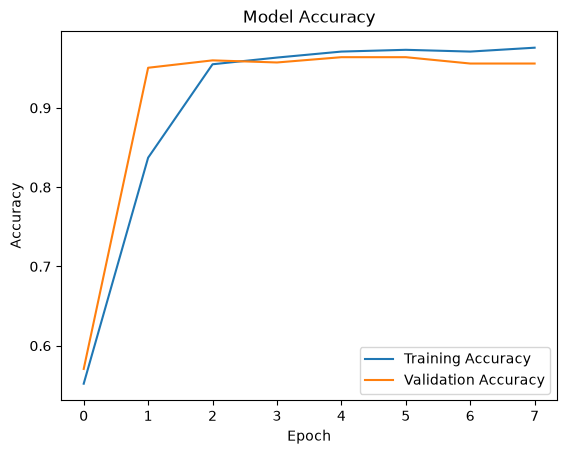

In [51]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()